
# EDA consolidado — Port Lead Time Prediction

Este notebook foi pensado para fazer uma análise exploratória **única e consolidada** sobre a base:

`data/processed/eda_base.parquet`

Ele cobre:

- visão geral e cobertura da base
- distribuição dos targets
- análise por porto, estado e região
- análise temporal
- análise meteorológica
- análise de congestionamento
- dependências e associações
- mapas e visualizações geográficas

> **Observação:** a lógica de tratamento, integração e feature engineering deve continuar em `src/`.  
> O notebook fica responsável por **explorar, visualizar e interpretar** os resultados.



## 0. Dependências sugeridas

Se necessário, instale localmente:

```bash
pip install pandas numpy matplotlib seaborn plotly pyarrow scipy
```

Se quiser exportar gráficos Plotly como imagem estática:

```bash
pip install kaleido
```


In [1]:

# Project path setup

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction


In [2]:

# Imports

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import spearmanr


In [3]:

# Global paths

EDA_BASE_PATH = PROJECT_ROOT / "data" / "processed" / "eda_base.parquet"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "eda"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(EDA_BASE_PATH)


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\data\processed\eda_base.parquet



## 1. Carregar a base consolidada


In [4]:

# Load analytical base

df = pd.read_parquet(EDA_BASE_PATH)

print(df.shape)
df.head()


(141895, 108)


,port_call_id,port,port_name,imo,vessel_id,vessel_name,operation_type,source_port,source_port_name,destination_port,...,temperature_2m_mean_prev_3d,wind_speed_10m_max_prev_3d,wind_gusts_10m_max_prev_3d,rain_sum_prev_7d,precipitation_hours_prev_7d,temperature_2m_mean_prev_7d,wind_speed_10m_max_prev_7d,wind_gusts_10m_max_prev_7d,has_port_reference,has_weather_data
0,561202021,BR052001,TERMINAL FLUVIAL DE JURUTI,9620310,<NA>,WHITE WHALE,Carga,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,BR052,...,26.466667,11.5,26.6,142.2,89.0,26.914286,14.2,31.7,1,1
1,4172022,BR052001,TERMINAL FLUVIAL DE JURUTI,9304241,<NA>,GOOD HOPE MAX,Carga,BR052,JURUTI,BRAMW001,...,25.966667,8.9,23.4,159.9,111.0,26.242857,12.2,27.7,1,1
2,7012022,BR052001,TERMINAL FLUVIAL DE JURUTI,9628922,<NA>,AMBERJACK,Carga,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,BRAMW001,...,26.233333,9.2,26.6,162.8,119.0,25.900000,12.2,27.7,1,1
3,12292022,BR052001,TERMINAL FLUVIAL DE JURUTI,9473339,<NA>,JURUTI,Carga,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,BR052,...,26.700000,9.6,24.1,66.8,99.0,26.114286,10.6,26.6,1,1
4,19472022,BR052001,TERMINAL FLUVIAL DE JURUTI,9620310,<NA>,WHITE WHALE,Carga,BR052,JURUTI,BR052,...,27.400000,13.6,29.9,31.3,74.0,27.042857,13.6,29.9,1,1


In [5]:

# Basic normalization for categorical fields used in plots

REGION_ORDER = ["NORTE", "NORDESTE", "CENTRO-OESTE", "SUDESTE", "SUL"]

for col in ["region", "state", "city", "port_name", "arrival_shift", "arrival_season"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

if "region" in df.columns:
    df["region"] = df["region"].str.upper()
    df["region"] = pd.Categorical(df["region"], categories=REGION_ORDER, ordered=True)

df.dtypes.head(20)


port_call_id                         int64
port                        string[python]
port_name                   string[python]
imo                         string[python]
vessel_id                   string[python]
vessel_name                 string[python]
operation_type              string[python]
source_port                 string[python]
source_port_name            string[python]
destination_port            string[python]
destination_port_name       string[python]
arrival_port_ts             datetime64[ns]
berthing_ts                 datetime64[ns]
unberthing_ts               datetime64[ns]
departure_port_ts           datetime64[ns]
port_display                string[python]
source_port_display         string[python]
destination_port_display    string[python]
has_arrival_port_ts                   bool
has_berthing_ts                       bool
dtype: object


## 2. Configuração visual e helpers


In [6]:

# Visual defaults

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12


In [7]:

# Helper definitions

TARGETS = [
    "t_wait_for_berthing_h",
    "t_operation_h",
    "t_post_operation_h",
    "t_total_port_stay_h",
]

TARGET_LABELS = {
    "t_wait_for_berthing_h": "Wait for Berthing (hours)",
    "t_operation_h": "Operation Time (hours)",
    "t_post_operation_h": "Post-Operation Time (hours)",
    "t_total_port_stay_h": "Total Port Stay (hours)",
}

NUMERIC_FEATURES = [
    "arrival_month",
    "arrival_dayofweek",
    "arrival_hour",
    "arrivals_same_day_port",
    "arrivals_prev_day_port",
    "arrivals_prev_7d_avg_port",
    "avg_wait_prev_20_calls_port",
    "avg_operation_prev_20_calls_port",
    "std_wait_prev_20_calls_port",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "precipitation_hours",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
    "rain_sum_prev_1d",
    "temperature_2m_mean_prev_1d",
    "wind_speed_10m_max_prev_1d",
    "wind_gusts_10m_max_prev_1d",
    "rain_sum_prev_3d",
    "precipitation_hours_prev_3d",
    "temperature_2m_mean_prev_3d",
    "wind_speed_10m_max_prev_3d",
    "wind_gusts_10m_max_prev_3d",
    "rain_sum_prev_7d",
    "precipitation_hours_prev_7d",
    "temperature_2m_mean_prev_7d",
    "wind_speed_10m_max_prev_7d",
    "wind_gusts_10m_max_prev_7d",
]

CATEGORICAL_FEATURES = [
    "region",
    "state",
    "city",
    "port_name",
    "arrival_shift",
    "arrival_season",
    "arrival_is_weekend",
]

TOP_N_PORTS = 15

def save_current_fig(filename: str) -> None:
    """Save current matplotlib figure."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

def build_target_summary(df_in: pd.DataFrame, target_cols: list[str]) -> pd.DataFrame:
    """Build descriptive statistics for target columns."""
    rows = []
    for col in target_cols:
        s = df_in[col].dropna()
        rows.append(
            {
                "target": col,
                "count": s.count(),
                "mean": s.mean(),
                "median": s.median(),
                "std": s.std(),
                "cv": s.std() / s.mean() if s.mean() not in [0, np.nan] else np.nan,
                "min": s.min(),
                "p10": s.quantile(0.10),
                "p25": s.quantile(0.25),
                "p75": s.quantile(0.75),
                "p90": s.quantile(0.90),
                "p95": s.quantile(0.95),
                "max": s.max(),
                "skew": s.skew(),
            }
        )
    return pd.DataFrame(rows)

def top_ports(df_in: pd.DataFrame, n: int = TOP_N_PORTS) -> list[str]:
    """Return the most frequent ports."""
    return (
        df_in["port_name"]
        .value_counts(dropna=True)
        .head(n)
        .index
        .tolist()
    )

def qcut_safe(series: pd.Series, q: int = 5, prefix: str = "Q") -> pd.Series:
    """Create quantile bins safely even with duplicate values."""
    ranks = series.rank(method="first")
    return pd.qcut(ranks, q=q, labels=[f"{prefix}{i}" for i in range(1, q + 1)])

def spearman_table(df_in: pd.DataFrame, features: list[str], targets: list[str]) -> pd.DataFrame:
    """Build a long table of Spearman correlations."""
    rows = []
    for feature in features:
        if feature not in df_in.columns:
            continue
        for target in targets:
            if target not in df_in.columns:
                continue
            tmp = df_in[[feature, target]].dropna()
            if len(tmp) < 20:
                continue
            corr, pvalue = spearmanr(tmp[feature], tmp[target])
            rows.append(
                {
                    "feature": feature,
                    "target": target,
                    "spearman_corr": corr,
                    "abs_spearman_corr": abs(corr),
                    "pvalue": pvalue,
                    "n_obs": len(tmp),
                }
            )
    return pd.DataFrame(rows)

def add_year_month(df_in: pd.DataFrame) -> pd.DataFrame:
    """Create year-month key for temporal heatmaps."""
    df_out = df_in.copy()
    if "arrival_port_ts" in df_out.columns:
        df_out["arrival_year_month"] = pd.to_datetime(df_out["arrival_port_ts"]).dt.to_period("M").astype(str)
    return df_out



## 3. Snapshot geral da base

Aqui a ideia é entender volume, cobertura e composição da base antes de mergulhar nos targets.


In [8]:

# Quick overview

overview = {
    "n_rows": len(df),
    "n_ports": df["port"].nunique(dropna=True) if "port" in df.columns else np.nan,
    "n_states": df["state"].nunique(dropna=True) if "state" in df.columns else np.nan,
    "n_regions": df["region"].nunique(dropna=True) if "region" in df.columns else np.nan,
    "date_min": df["arrival_port_ts"].min() if "arrival_port_ts" in df.columns else pd.NaT,
    "date_max": df["arrival_port_ts"].max() if "arrival_port_ts" in df.columns else pd.NaT,
    "weather_coverage_pct": df["has_weather_data"].mean() * 100 if "has_weather_data" in df.columns else np.nan,
}
pd.Series(overview)


n_rows                               141895
n_ports                                 113
n_states                                 17
n_regions                                 4
date_min                2013-04-11 19:30:00
date_max                2025-12-31 23:00:00
weather_coverage_pct                  100.0
dtype: object

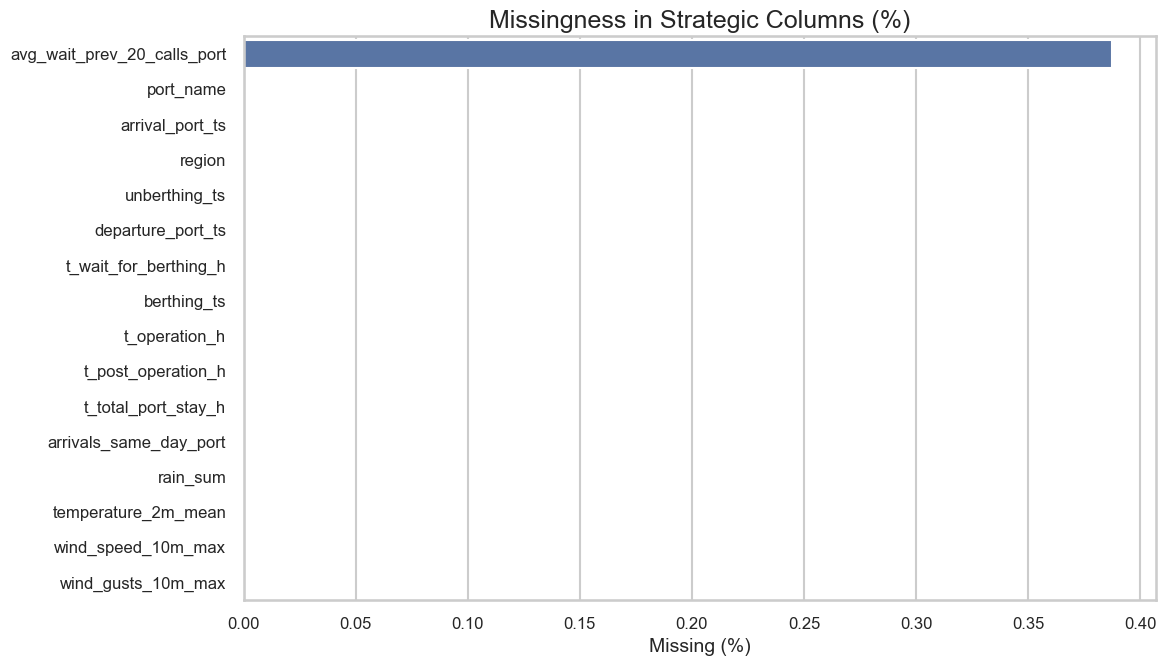

In [9]:

# Missingness heatmap for strategic columns

strategic_cols = [
    "port_name",
    "region",
    "arrival_port_ts",
    "berthing_ts",
    "unberthing_ts",
    "departure_port_ts",
    "t_wait_for_berthing_h",
    "t_operation_h",
    "t_post_operation_h",
    "t_total_port_stay_h",
    "arrivals_same_day_port",
    "avg_wait_prev_20_calls_port",
    "rain_sum",
    "temperature_2m_mean",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
]

strategic_cols = [c for c in strategic_cols if c in df.columns]

missing_df = (
    df[strategic_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .mul(100)
    .reset_index()
    .rename(columns={"index": "column"})
)

plt.figure(figsize=(12, 7))
sns.barplot(data=missing_df, x="missing_pct", y="column")
plt.title("Missingness in Strategic Columns (%)")
plt.xlabel("Missing (%)")
plt.ylabel("")
save_current_fig("01_missingness_strategic_columns.png")


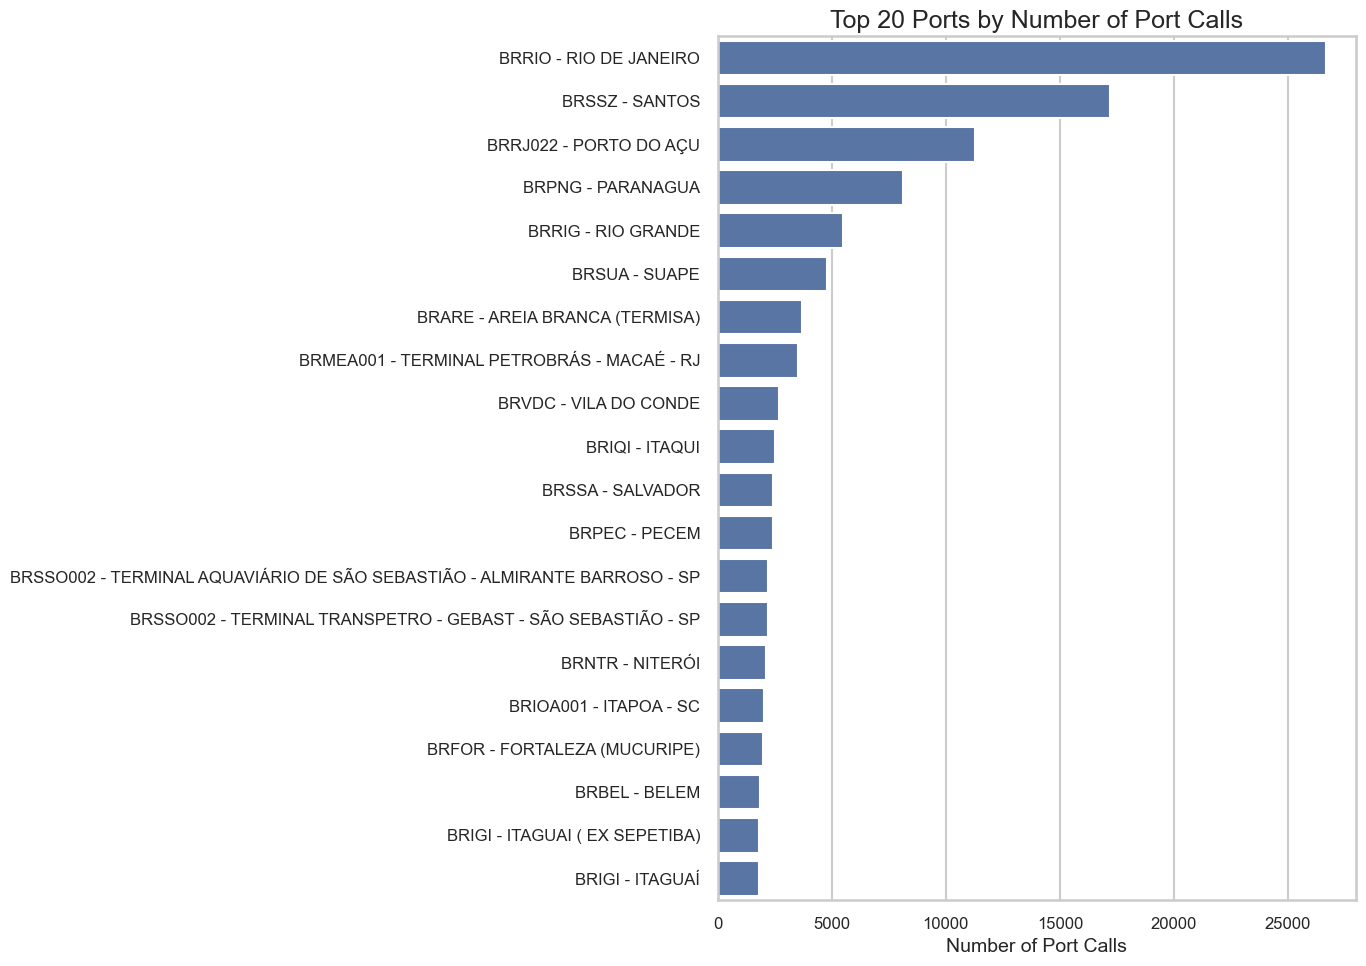

In [10]:

# Port volume chart

port_counts = (
    df[["port", "port_name", "port_display"]]
    .drop_duplicates()
    .merge(
        df["port"].value_counts().rename("n_port_calls"),
        left_on="port",
        right_index=True,
        how="left",
    )
    .sort_values("n_port_calls", ascending=False)
    .head(20)
    .copy()
)

plt.figure(figsize=(14, 10))
sns.barplot(data=port_counts, x="n_port_calls", y="port_display")
plt.title("Top 20 Ports by Number of Port Calls")
plt.xlabel("Number of Port Calls")
plt.ylabel("")
save_current_fig("02_top_ports_by_volume.png")



## 4. Estatística descritiva dos targets

Aqui vamos explorar a forma das distribuições, assimetria, caudas e dispersão.


In [11]:

# Target summary table

target_summary = build_target_summary(df, TARGETS)
target_summary.to_csv(TABLES_DIR / "eda_target_summary.csv", index=False)
target_summary


,target,count,mean,median,std,cv,min,p10,p25,p75,p90,p95,max,skew
0,t_wait_for_berthing_h,141895,10.323023,0.000000,63.834458,6.183698,0.000000,0.000000,0.000000,0.000000,6.900000,40.626667,3000.950000,14.770940
1,t_operation_h,141895,99.676047,35.416667,791.800350,7.943737,0.016667,9.333333,17.500000,74.333333,153.566667,254.610000,77638.716667,58.470717
2,t_post_operation_h,141895,0.830300,0.000000,19.892532,23.958244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3958.166667,112.312585
3,t_total_port_stay_h,141895,110.829370,39.350000,795.278469,7.175701,0.016667,10.033333,19.083333,85.250000,183.550000,313.583333,77638.716667,57.689346


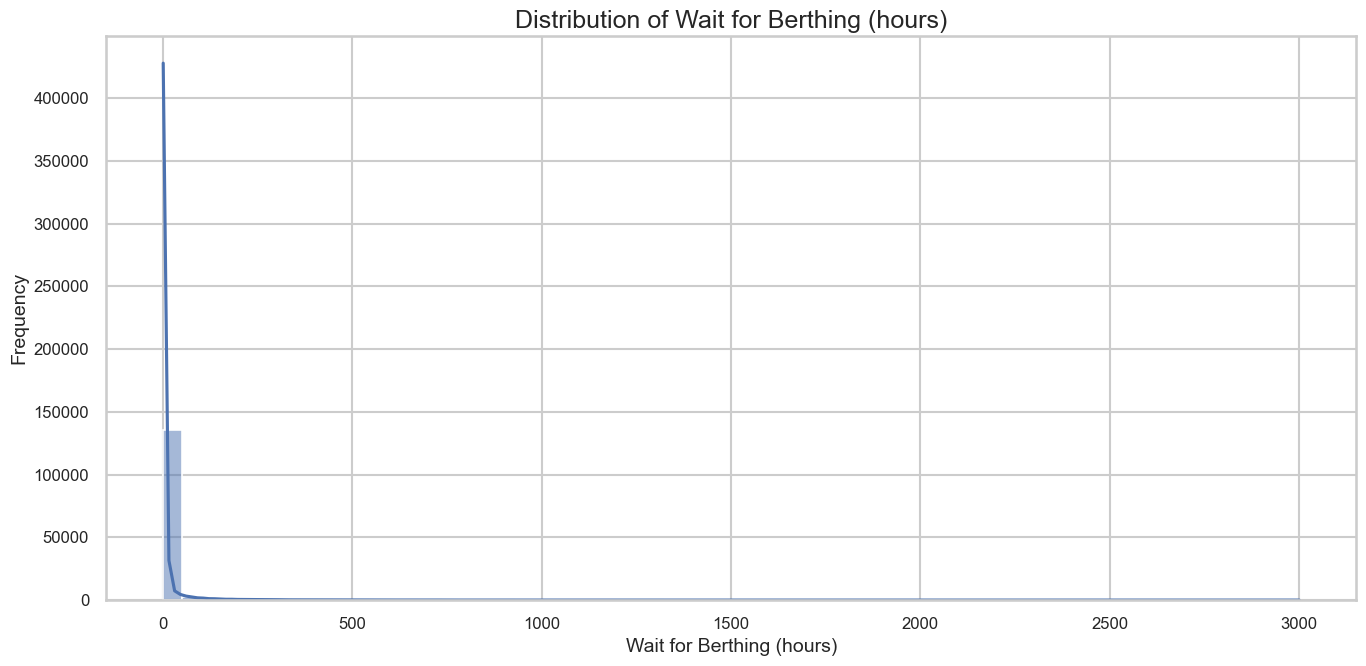

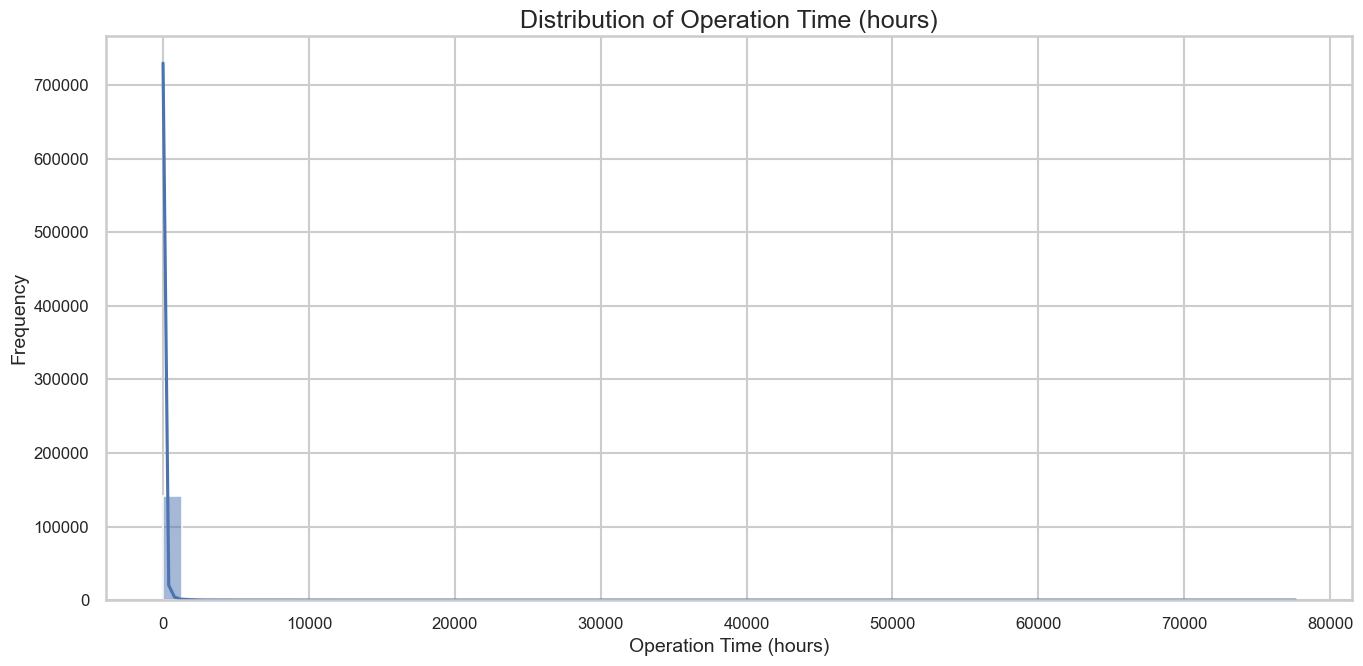

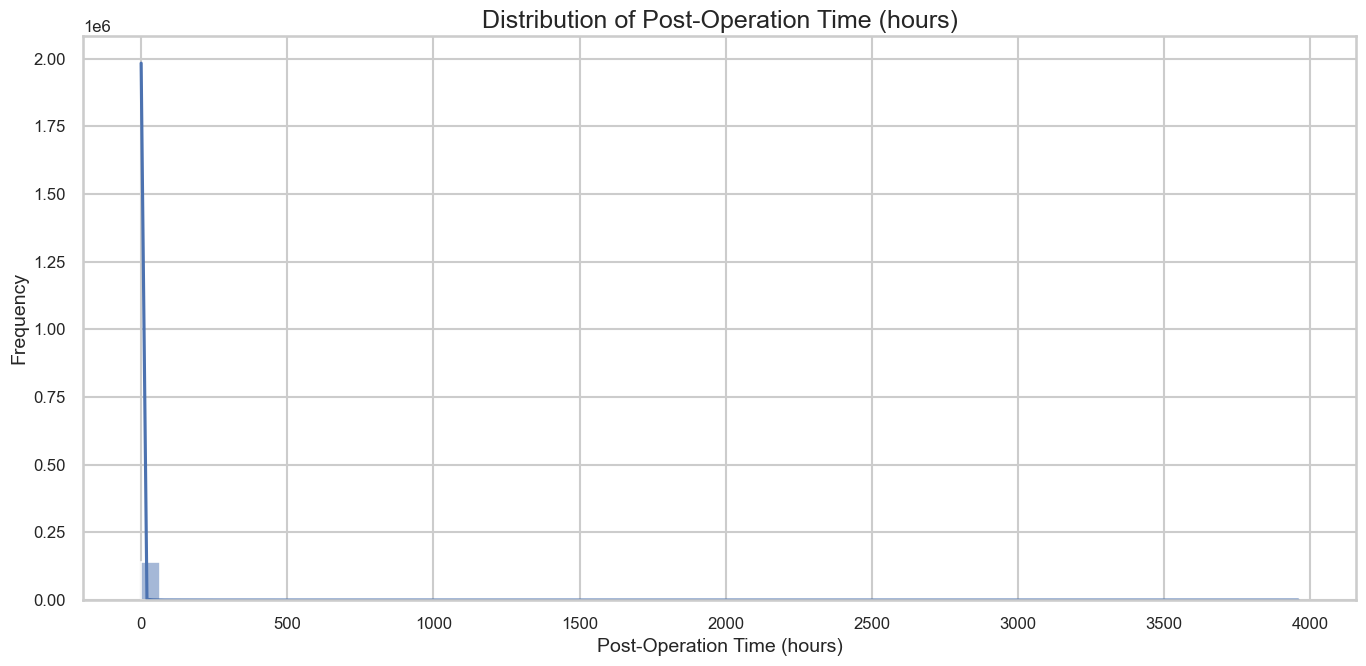

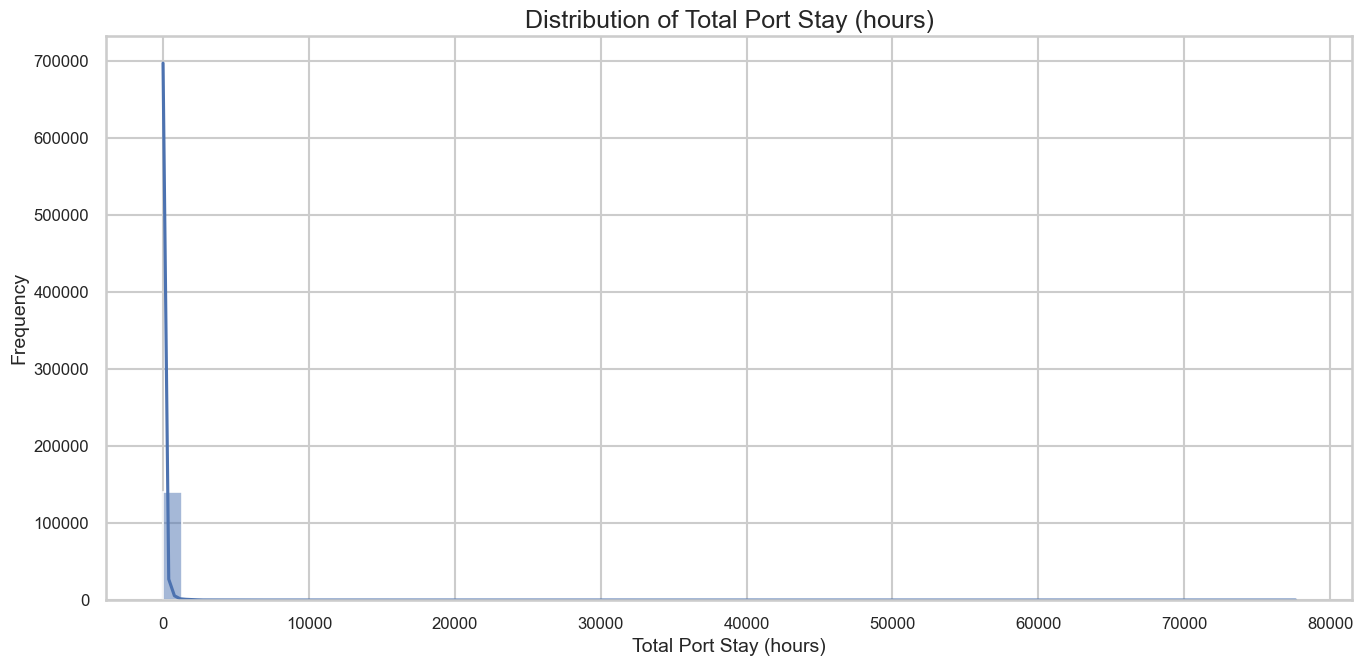

In [12]:

# Histograms + KDE for each target

for target in TARGETS:
    plt.figure(figsize=(14, 7))
    sns.histplot(df[target].dropna(), bins=60, kde=True)
    plt.title(f"Distribution of {TARGET_LABELS[target]}")
    plt.xlabel(TARGET_LABELS[target])
    plt.ylabel("Frequency")
    save_current_fig(f"10_hist_{target}.png")


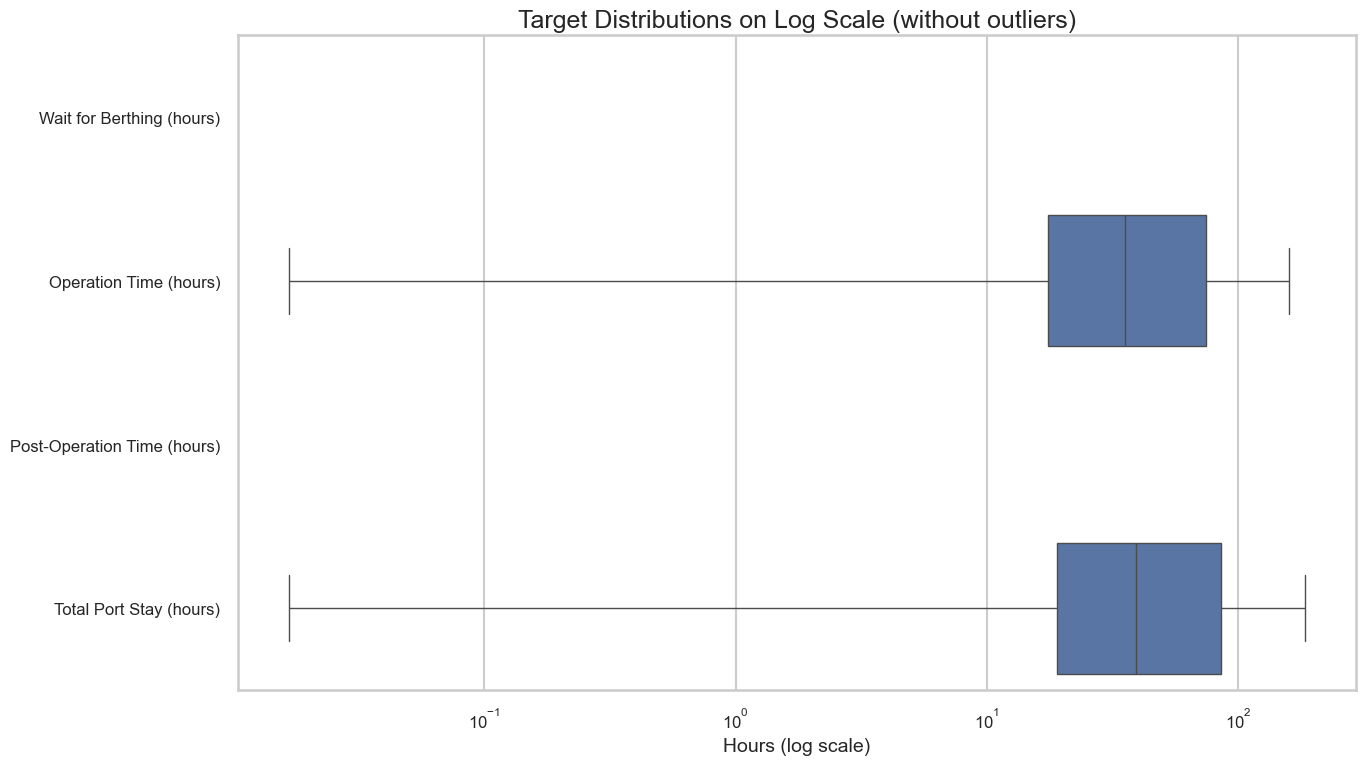

In [13]:

# Log-scale boxplots for targets

plot_df = df[TARGETS].melt(var_name="target", value_name="value").dropna()
plot_df["target_label"] = plot_df["target"].map(TARGET_LABELS)

plt.figure(figsize=(14, 8))
sns.boxplot(data=plot_df, x="value", y="target_label", orient="h", showfliers=False)
plt.xscale("log")
plt.title("Target Distributions on Log Scale (without outliers)")
plt.xlabel("Hours (log scale)")
plt.ylabel("")
save_current_fig("11_targets_boxplot_logscale.png")


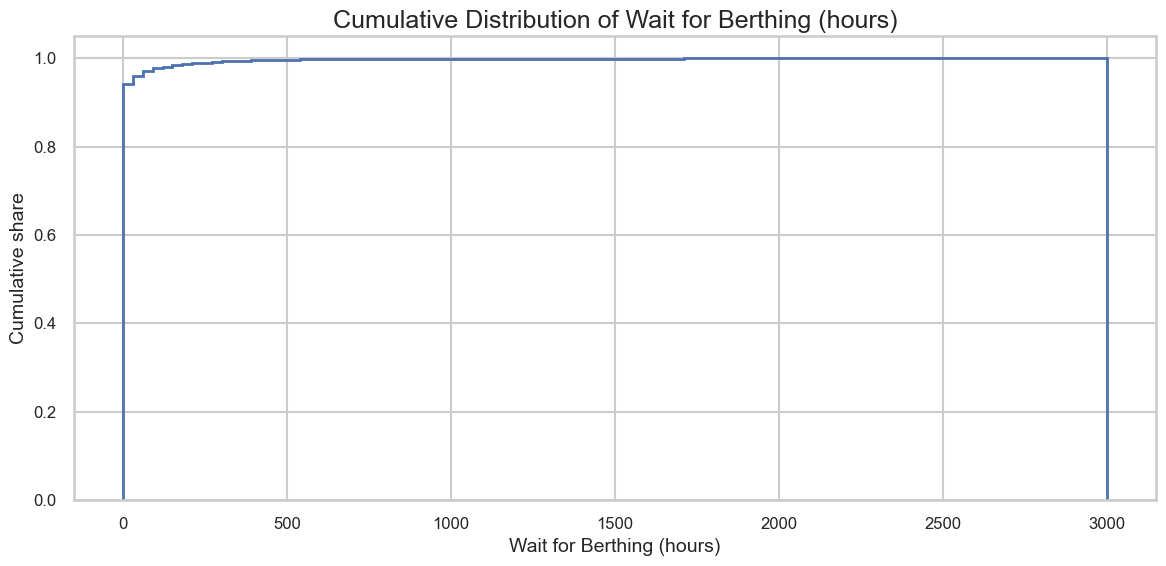

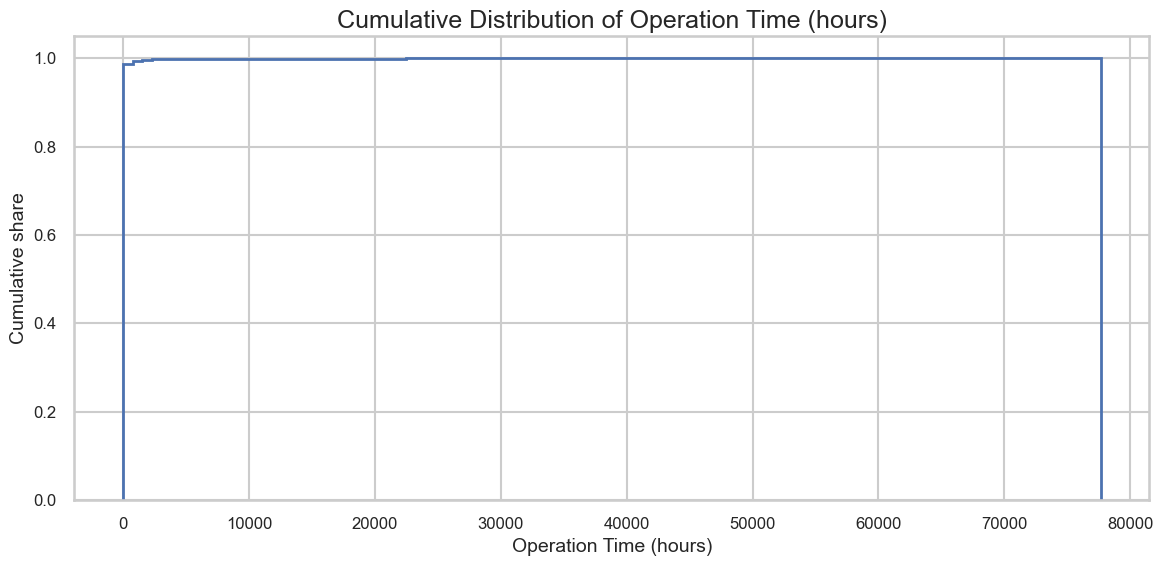

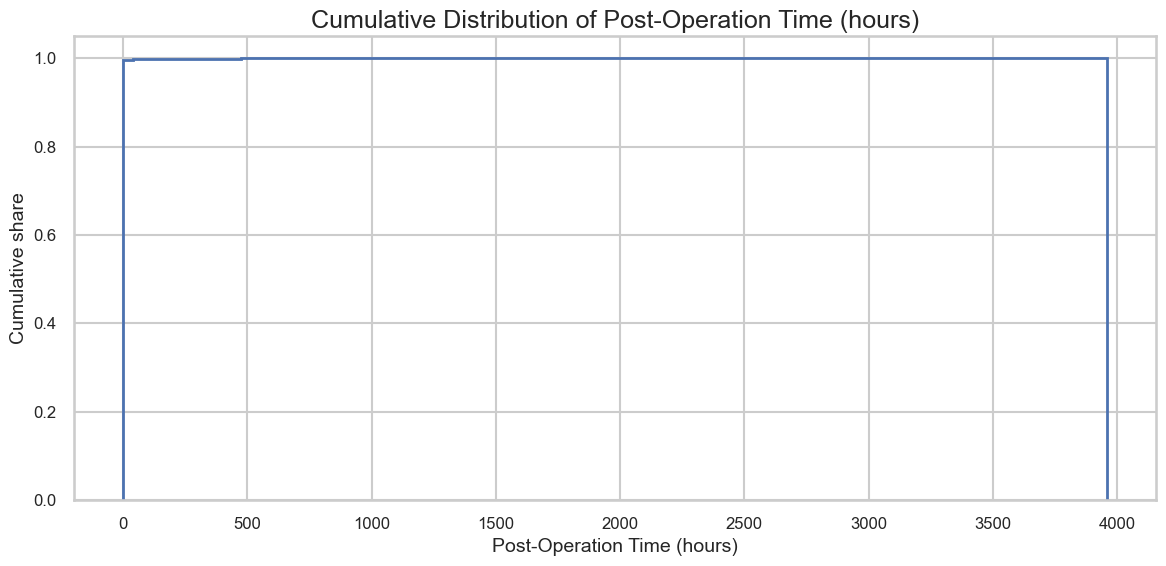

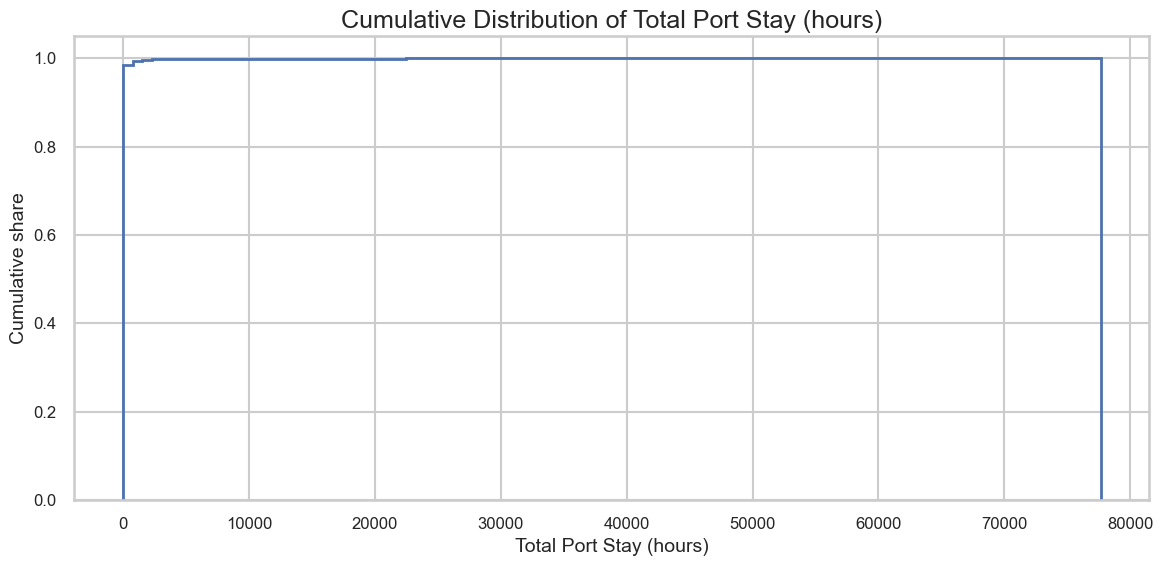

In [14]:

# ECDF-style view using cumulative histogram

for target in TARGETS:
    plt.figure(figsize=(12, 6))
    plt.hist(df[target].dropna(), bins=100, cumulative=True, density=True, histtype="step", linewidth=2)
    plt.title(f"Cumulative Distribution of {TARGET_LABELS[target]}")
    plt.xlabel(TARGET_LABELS[target])
    plt.ylabel("Cumulative share")
    save_current_fig(f"12_ecdf_{target}.png")



## 5. Análise por porto

Aqui a ideia é ver onde a variabilidade é maior e quais portos concentram mais permanência e espera.


In [18]:

# Top ports by target median and variability

top_ports_list = top_ports(df, n=TOP_N_PORTS)
df_top_ports = df[df["port_name"].isin(top_ports_list)].copy()

port_target_stats = (
    df_top_ports.groupby("port_name")
    .agg(
        n_port_calls=("port_call_id", "count") if "port_call_id" in df_top_ports.columns else ("port_name", "count"),
        median_wait=("t_wait_for_berthing_h", "median"),
        median_total=("t_total_port_stay_h", "median"),
        std_wait=("t_wait_for_berthing_h", "std"),
        std_total=("t_total_port_stay_h", "std"),
    )
    .reset_index()
    .sort_values("median_total", ascending=False)
)

port_target_stats.to_csv(TABLES_DIR / "eda_port_target_stats.csv", index=False)
port_target_stats.head(20)


,port_name,n_port_calls,median_wait,median_total,std_wait,std_total
2,ITAQUI,2519,0.000000,61.116667,0.000000,107.310611
10,SANTOS,17214,0.000000,54.333333,136.587846,380.195409
14,VILA DO CONDE,2681,0.000000,50.416667,39.301089,98.204670
3,NITERÓI,2139,0.000000,47.583333,9.415540,1626.453581
11,SUAPE,4779,0.000000,46.200000,61.361357,1342.213752
8,RIO GRANDE,5483,0.000000,45.083333,12.247342,106.108337
7,RIO DE JANEIRO,26648,0.000000,43.166667,6.398476,1339.551610
13,TERMINAL TRANSPETRO - GEBAST - SÃO SEBASTIÃO - SP,2012,0.000000,35.750000,24.370876,76.250721
4,PARANAGUA,8115,0.000000,31.950000,6.052917,207.401469
12,TERMINAL PETROBRÁS - MACAÉ - RJ,3531,4.666667,28.500000,24.093187,66.978837


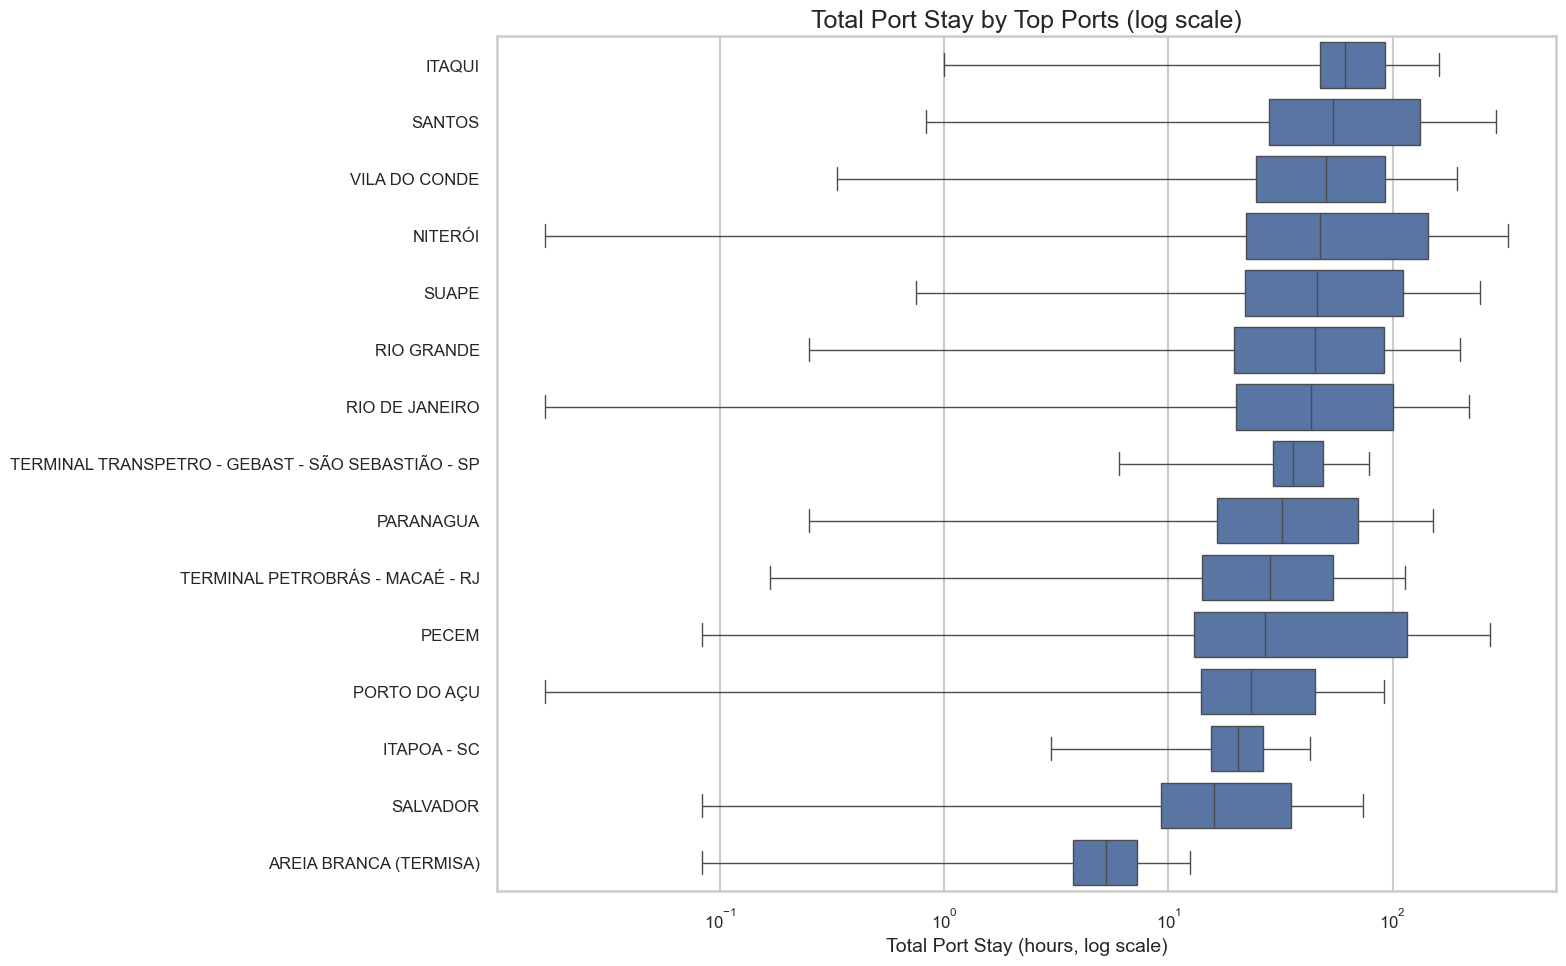

In [19]:

# Boxplot by top ports - total port stay

plt.figure(figsize=(16, 10))
sns.boxplot(
    data=df_top_ports,
    x="t_total_port_stay_h",
    y="port_name",
    order=port_target_stats["port_name"].tolist(),
    showfliers=False,
)
plt.xscale("log")
plt.title("Total Port Stay by Top Ports (log scale)")
plt.xlabel("Total Port Stay (hours, log scale)")
plt.ylabel("")
save_current_fig("20_total_port_stay_by_top_ports.png")


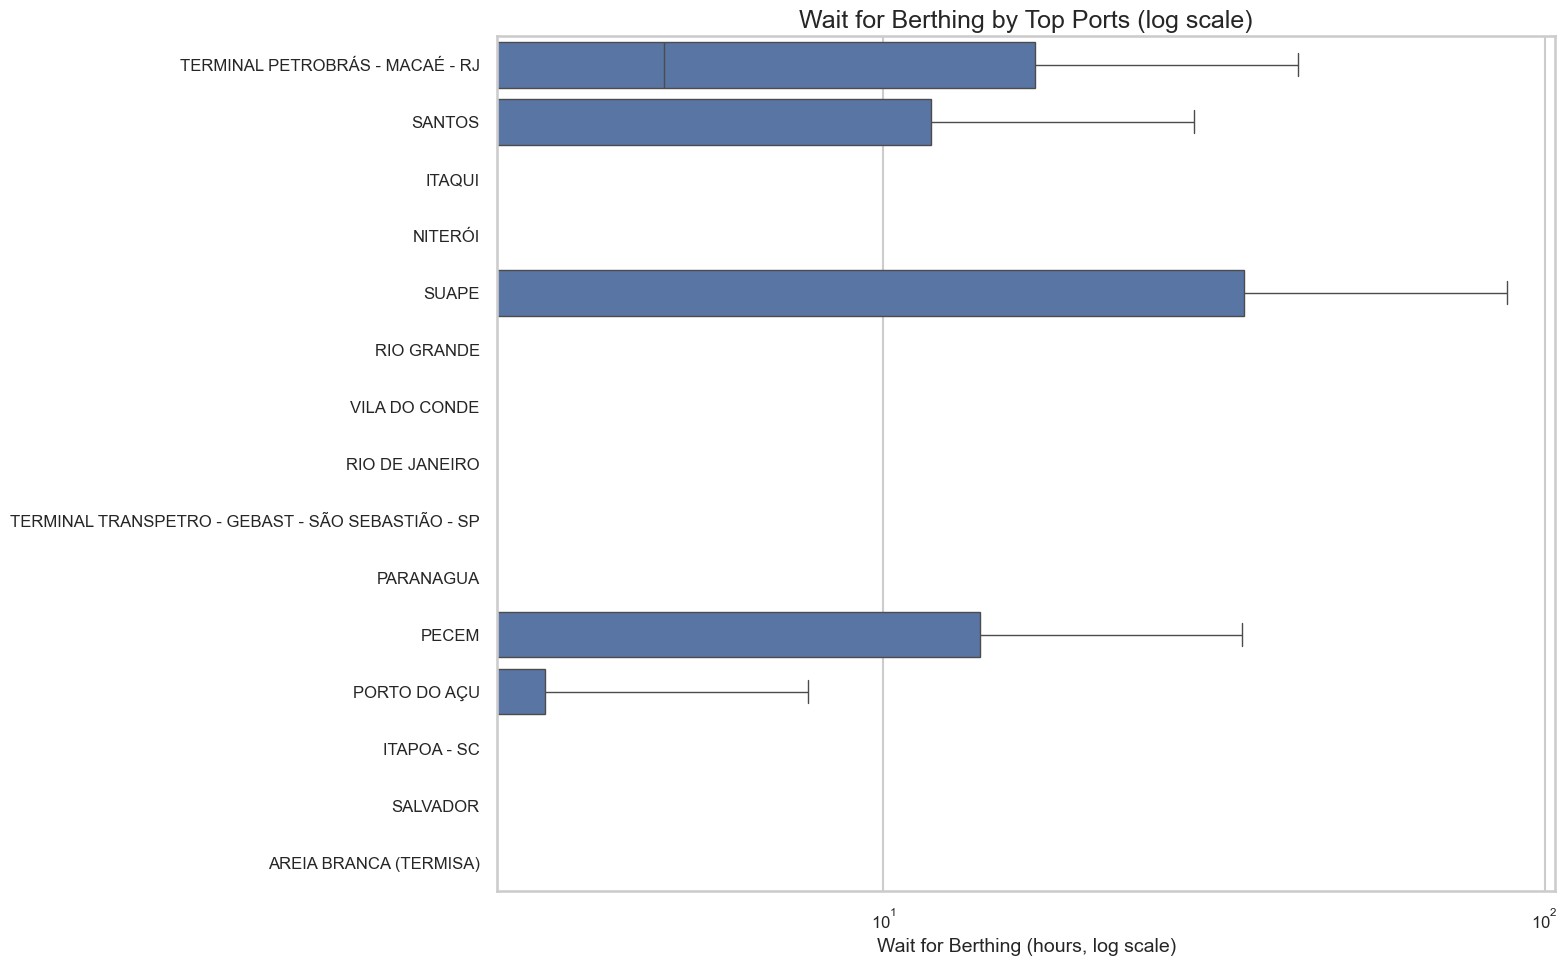

In [20]:

# Boxplot by top ports - wait for berthing

plt.figure(figsize=(16, 10))
sns.boxplot(
    data=df_top_ports,
    x="t_wait_for_berthing_h",
    y="port_name",
    order=port_target_stats.sort_values("median_wait", ascending=False)["port_name"].tolist(),
    showfliers=False,
)
plt.xscale("log")
plt.title("Wait for Berthing by Top Ports (log scale)")
plt.xlabel("Wait for Berthing (hours, log scale)")
plt.ylabel("")
save_current_fig("21_wait_for_berthing_by_top_ports.png")


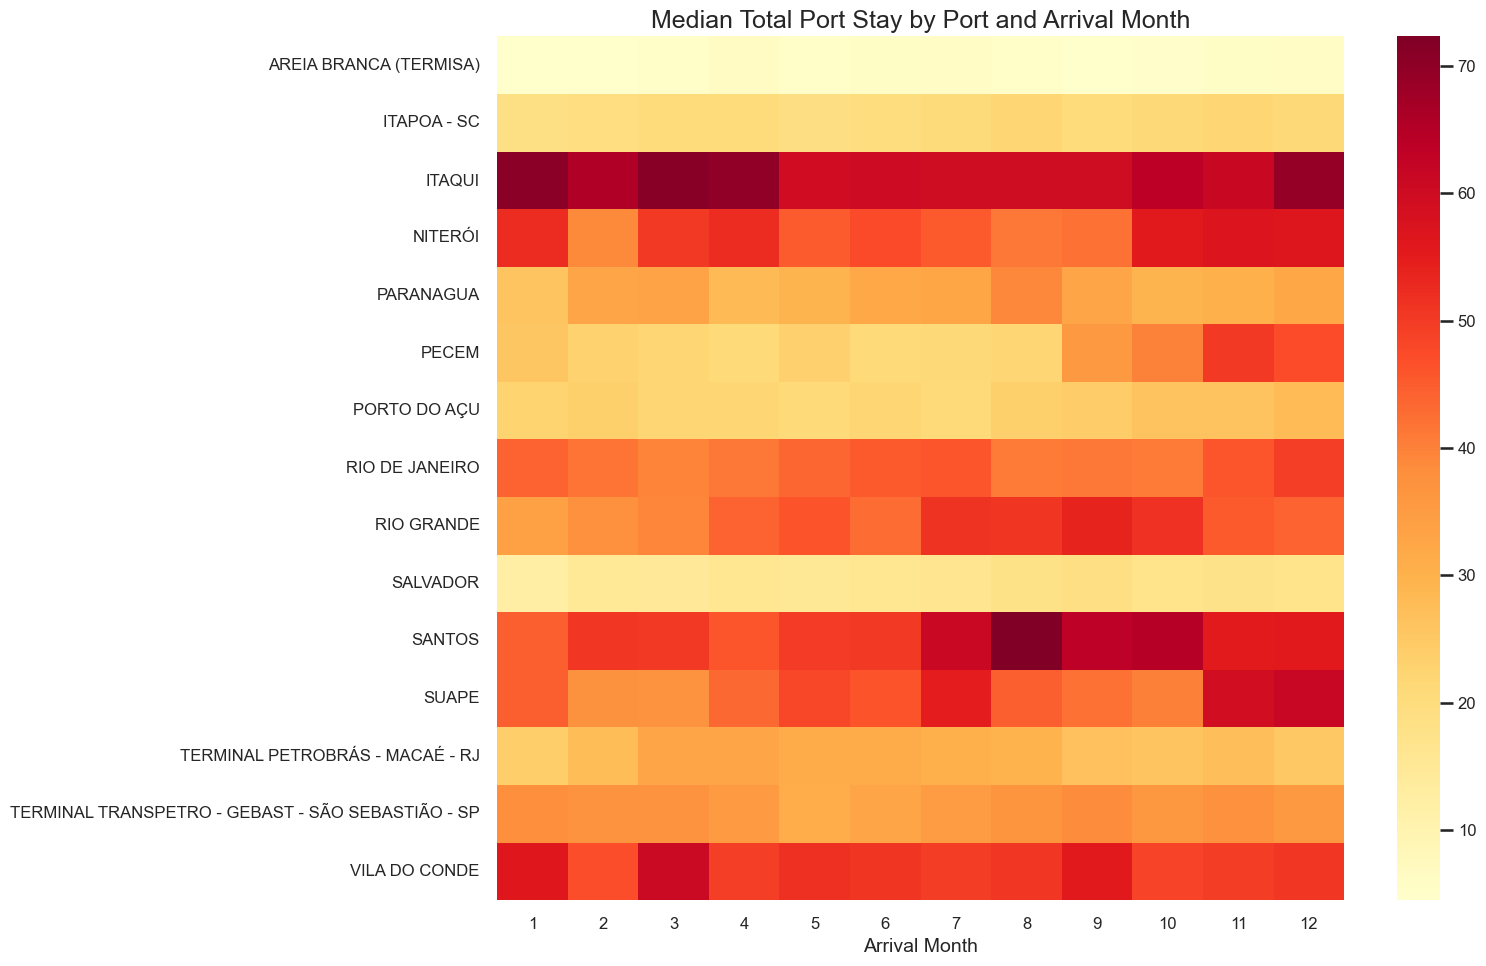

In [21]:

# Port x month heatmap for median total stay

df_heat = add_year_month(df_top_ports.copy())

pivot_port_month = (
    df_heat.pivot_table(
        index="port_name",
        columns="arrival_month",
        values="t_total_port_stay_h",
        aggfunc="median",
    )
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_port_month, cmap="YlOrRd", annot=False)
plt.title("Median Total Port Stay by Port and Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("")
save_current_fig("22_heatmap_port_month_total_stay.png")



## 6. Análise por região, estado e geografia

Como você quis trazer uma camada geográfica forte, aqui entram:
- distribuições por região
- dispersão por região
- mapas com pontos de porto
- mapas com agregação regional


In [22]:

# Region-level summary

if "region" in df.columns:
    region_stats = (
        df.groupby("region", observed=True)
        .agg(
            n_port_calls=("port_call_id", "count") if "port_call_id" in df.columns else ("region", "count"),
            median_wait=("t_wait_for_berthing_h", "median"),
            median_operation=("t_operation_h", "median"),
            median_total=("t_total_port_stay_h", "median"),
            std_wait=("t_wait_for_berthing_h", "std"),
            std_total=("t_total_port_stay_h", "std"),
        )
        .reset_index()
    )
    region_stats.to_csv(TABLES_DIR / "eda_region_stats.csv", index=False)
    region_stats


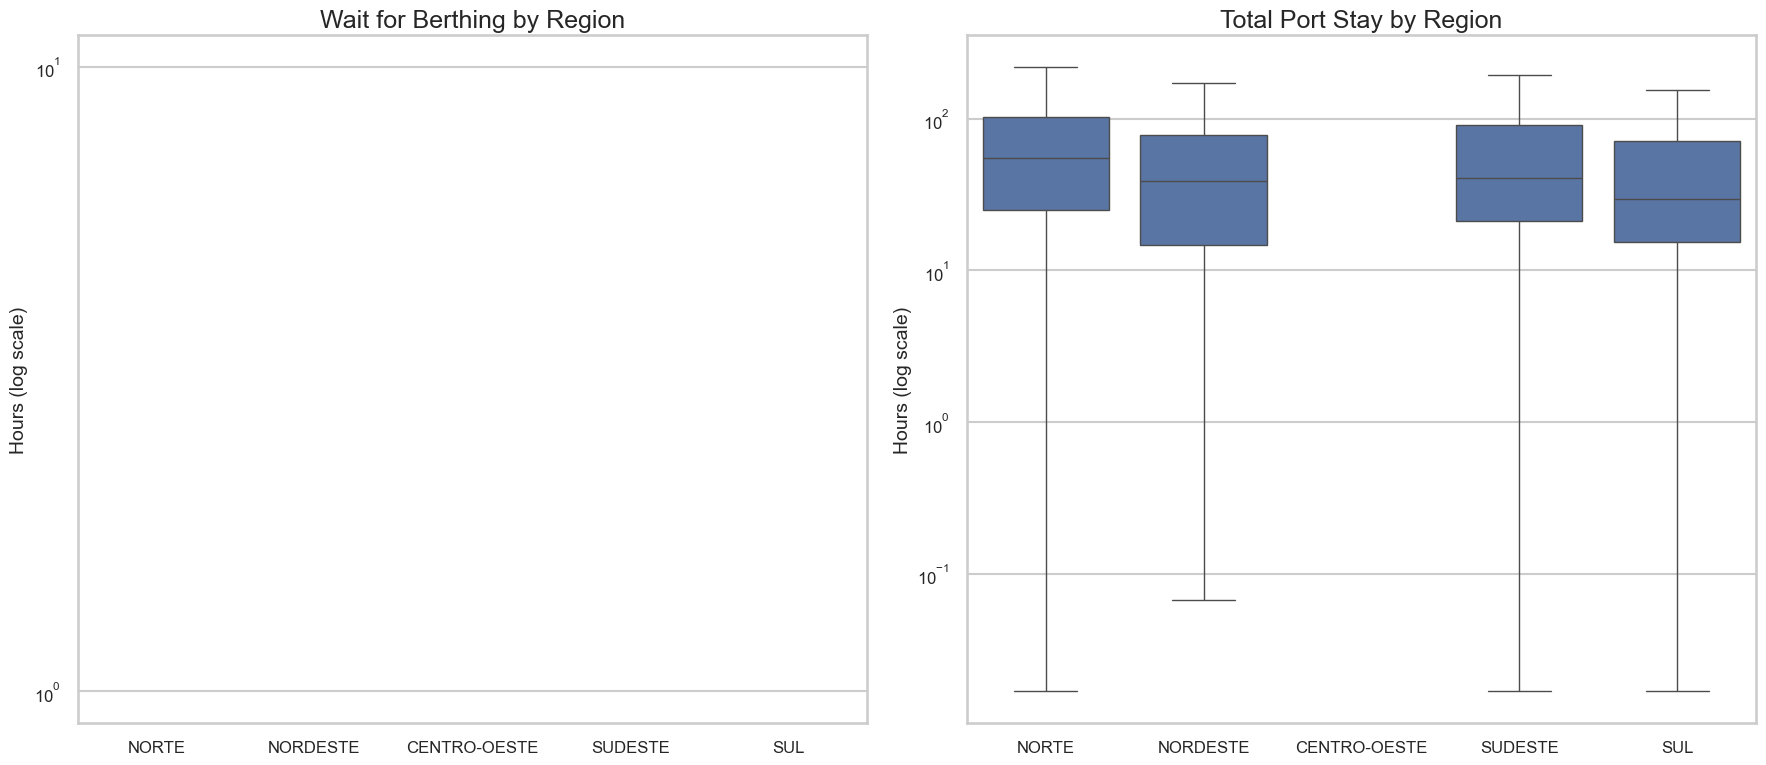

In [23]:

# Region boxplots

if "region" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    sns.boxplot(
        data=df,
        x="region",
        y="t_wait_for_berthing_h",
        showfliers=False,
        ax=axes[0],
    )
    axes[0].set_yscale("log")
    axes[0].set_title("Wait for Berthing by Region")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Hours (log scale)")

    sns.boxplot(
        data=df,
        x="region",
        y="t_total_port_stay_h",
        showfliers=False,
        ax=axes[1],
    )
    axes[1].set_yscale("log")
    axes[1].set_title("Total Port Stay by Region")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Hours (log scale)")

    save_current_fig("30_boxplots_by_region.png")


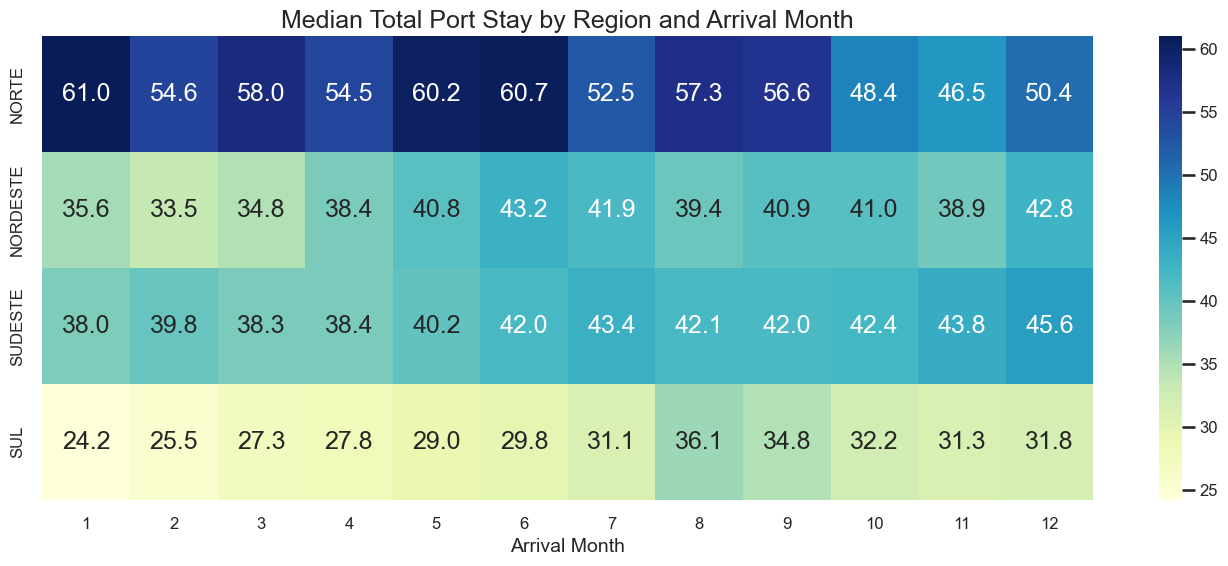

In [24]:

# Region x month heatmap

if "region" in df.columns and "arrival_month" in df.columns:
    pivot_region_month = (
        df.pivot_table(
            index="region",
            columns="arrival_month",
            values="t_total_port_stay_h",
            aggfunc="median",
        )
    )

    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot_region_month, cmap="YlGnBu", annot=True, fmt=".1f")
    plt.title("Median Total Port Stay by Region and Arrival Month")
    plt.xlabel("Arrival Month")
    plt.ylabel("")
    save_current_fig("31_heatmap_region_month_total_stay.png")


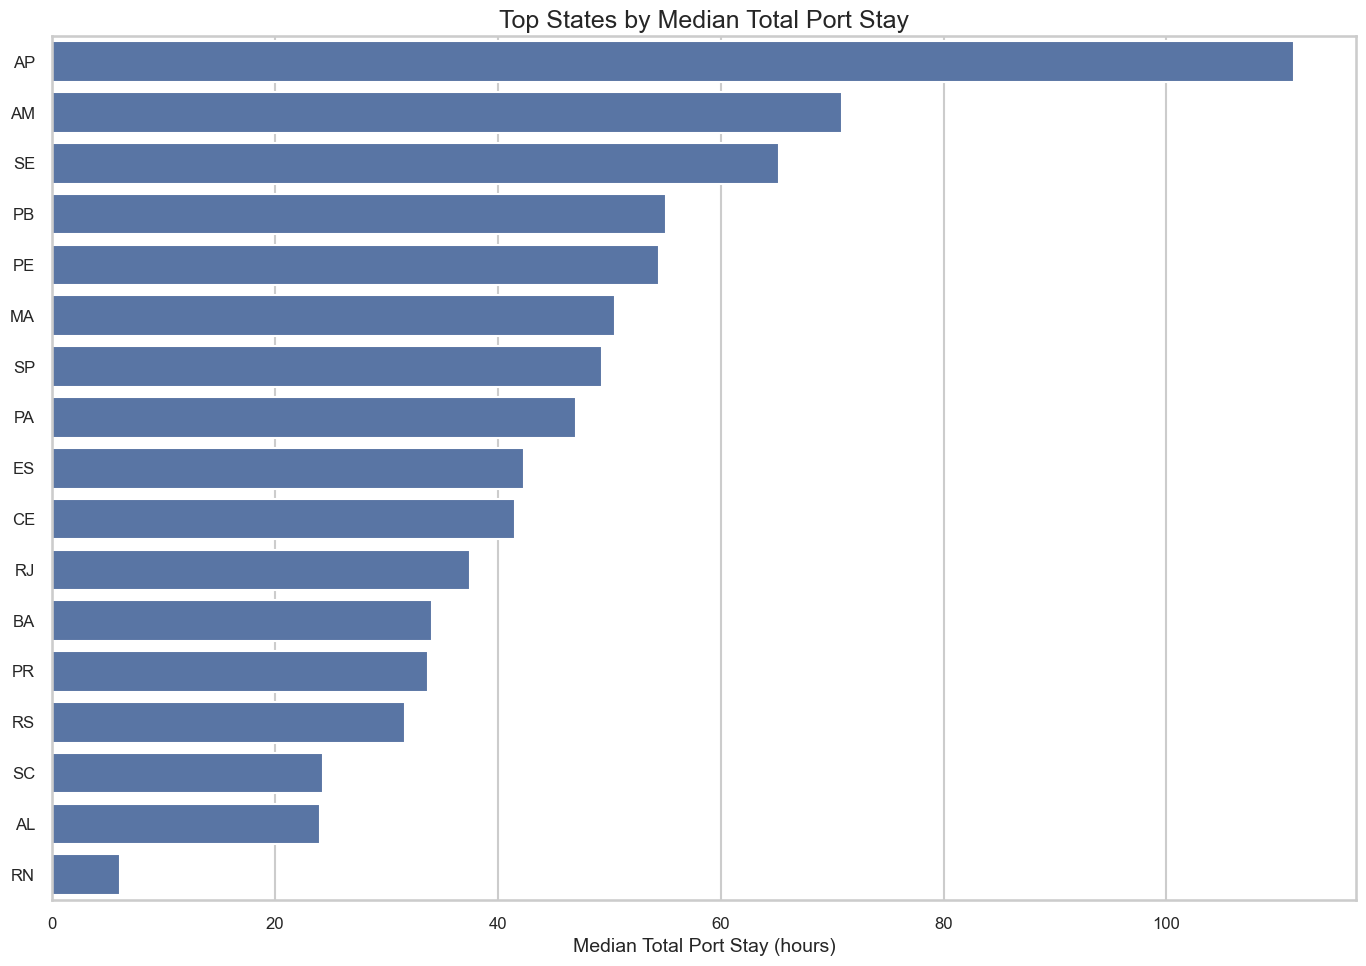

In [25]:

# State-level ranking for median total stay

if "state" in df.columns:
    state_stats = (
        df.groupby("state")
        .agg(
            n_port_calls=("port_call_id", "count") if "port_call_id" in df.columns else ("state", "count"),
            median_total=("t_total_port_stay_h", "median"),
            std_total=("t_total_port_stay_h", "std"),
        )
        .reset_index()
        .query("n_port_calls >= 20")
        .sort_values("median_total", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(14, 10))
    sns.barplot(data=state_stats, x="median_total", y="state")
    plt.title("Top States by Median Total Port Stay")
    plt.xlabel("Median Total Port Stay (hours)")
    plt.ylabel("")
    save_current_fig("32_top_states_median_total_stay.png")


In [26]:

# Geographic aggregation by port for mapping

geo_port = (
    df.groupby(["port_name", "city", "state", "region", "latitude", "longitude"], dropna=False)
    .agg(
        n_port_calls=("port_call_id", "count") if "port_call_id" in df.columns else ("port_name", "count"),
        median_wait=("t_wait_for_berthing_h", "median"),
        median_total=("t_total_port_stay_h", "median"),
        std_wait=("t_wait_for_berthing_h", "std"),
        std_total=("t_total_port_stay_h", "std"),
        weather_coverage=("has_weather_data", "mean") if "has_weather_data" in df.columns else ("port_name", "size"),
    )
    .reset_index()
)

geo_port = geo_port.dropna(subset=["latitude", "longitude"])
geo_port.head()


MemoryError: Unable to allocate 39.4 GiB for an array with shape (5283567360,) and data type int64

In [ ]:

# Interactive bubble map: median total stay by port

fig = px.scatter_geo(
    geo_port,
    lat="latitude",
    lon="longitude",
    color="median_total",
    size="n_port_calls",
    hover_name="port_name",
    hover_data={
        "city": True,
        "state": True,
        "region": True,
        "median_wait": ":.2f",
        "median_total": ":.2f",
        "std_total": ":.2f",
        "n_port_calls": True,
        "latitude": False,
        "longitude": False,
    },
    scope="south america",
    projection="natural earth",
    title="Brazilian Ports — Median Total Port Stay (bubble size = volume)",
    color_continuous_scale="YlOrRd",
)
fig.update_geos(
    fitbounds="locations",
    visible=False,
    center={"lat": -14, "lon": -52},
)
fig.write_html(FIGURES_DIR / "33_map_ports_median_total_stay.html")
fig.show()


In [ ]:

# Interactive bubble map: variability by port

fig = px.scatter_geo(
    geo_port,
    lat="latitude",
    lon="longitude",
    color="std_total",
    size="std_total",
    hover_name="port_name",
    hover_data={
        "city": True,
        "state": True,
        "region": True,
        "median_total": ":.2f",
        "std_total": ":.2f",
        "n_port_calls": True,
        "latitude": False,
        "longitude": False,
    },
    scope="south america",
    projection="natural earth",
    title="Brazilian Ports — Variability of Total Port Stay (size and color = std)",
    color_continuous_scale="Turbo",
)
fig.update_geos(
    fitbounds="locations",
    visible=False,
    center={"lat": -14, "lon": -52},
)
fig.write_html(FIGURES_DIR / "34_map_ports_variability_total_stay.html")
fig.show()


In [ ]:

# Regional centroid map for a more synthetic regional view

if "region" in geo_port.columns:
    region_geo = (
        geo_port.groupby("region", observed=True)
        .agg(
            latitude=("latitude", "mean"),
            longitude=("longitude", "mean"),
            n_port_calls=("n_port_calls", "sum"),
            median_total=("median_total", "median"),
            std_total=("std_total", "mean"),
        )
        .reset_index()
        .dropna(subset=["latitude", "longitude"])
    )

    fig = px.scatter_geo(
        region_geo,
        lat="latitude",
        lon="longitude",
        color="median_total",
        size="std_total",
        text="region",
        hover_name="region",
        hover_data={
            "n_port_calls": True,
            "median_total": ":.2f",
            "std_total": ":.2f",
            "latitude": False,
            "longitude": False,
        },
        scope="south america",
        projection="natural earth",
        title="Brazilian Regions — Median Total Stay and Variability",
        color_continuous_scale="Viridis",
    )
    fig.update_traces(textposition="top center")
    fig.update_geos(
        fitbounds="locations",
        visible=False,
        center={"lat": -14, "lon": -52},
    )
    fig.write_html(FIGURES_DIR / "35_map_regions_variability_total_stay.html")
    fig.show()



## 7. Análise temporal

Aqui buscamos sazonalidade, padrões por horário, dia da semana, mês e turnos.


In [ ]:

# Monthly evolution of median targets

monthly = (
    df.groupby("arrival_month")
    .agg(
        median_wait=("t_wait_for_berthing_h", "median"),
        median_operation=("t_operation_h", "median"),
        median_total=("t_total_port_stay_h", "median"),
    )
    .reset_index()
)

plt.figure(figsize=(14, 7))
plt.plot(monthly["arrival_month"], monthly["median_wait"], marker="o", label="Median wait")
plt.plot(monthly["arrival_month"], monthly["median_operation"], marker="o", label="Median operation")
plt.plot(monthly["arrival_month"], monthly["median_total"], marker="o", label="Median total stay")
plt.title("Monthly Median Evolution of Main Targets")
plt.xlabel("Arrival Month")
plt.ylabel("Hours")
plt.legend()
save_current_fig("40_monthly_median_targets.png")


In [ ]:

# Arrival hour vs targets

hourly = (
    df.groupby("arrival_hour")
    .agg(
        median_wait=("t_wait_for_berthing_h", "median"),
        median_total=("t_total_port_stay_h", "median"),
        n=("port_call_id", "count") if "port_call_id" in df.columns else ("arrival_hour", "count"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(15, 7))
ax1.plot(hourly["arrival_hour"], hourly["median_wait"], marker="o", label="Median wait")
ax1.plot(hourly["arrival_hour"], hourly["median_total"], marker="o", label="Median total stay")
ax1.set_xlabel("Arrival Hour")
ax1.set_ylabel("Hours")
ax1.set_title("Arrival Hour vs Median Targets")

ax2 = ax1.twinx()
ax2.bar(hourly["arrival_hour"], hourly["n"], alpha=0.2, label="Volume")
ax2.set_ylabel("Number of port calls")

save_current_fig("41_arrival_hour_vs_targets.png")


In [ ]:

# Shift-based comparison

if "arrival_shift" in df.columns:
    plt.figure(figsize=(14, 8))
    sns.violinplot(
        data=df,
        x="arrival_shift",
        y="t_total_port_stay_h",
        inner="quartile",
        cut=0,
    )
    plt.yscale("log")
    plt.title("Total Port Stay by Arrival Shift")
    plt.xlabel("")
    plt.ylabel("Hours (log scale)")
    save_current_fig("42_total_stay_by_shift_violin.png")


In [ ]:

# Weekend effect

if "arrival_is_weekend" in df.columns:
    weekend_labels = {0: "Weekday", 1: "Weekend"}
    tmp = df.copy()
    tmp["arrival_is_weekend_label"] = tmp["arrival_is_weekend"].map(weekend_labels)

    plt.figure(figsize=(10, 7))
    sns.boxplot(
        data=tmp,
        x="arrival_is_weekend_label",
        y="t_wait_for_berthing_h",
        showfliers=False,
    )
    plt.yscale("log")
    plt.title("Wait for Berthing — Weekend vs Weekday")
    plt.xlabel("")
    plt.ylabel("Hours (log scale)")
    save_current_fig("43_wait_weekend_vs_weekday.png")



## 8. Análise meteorológica

Como seu weather está em grão diário, a leitura correta aqui é:
- clima do dia de chegada
- clima recente dos dias anteriores
- efeitos não lineares por faixas


In [ ]:

# Weather coverage by region

if "region" in df.columns and "has_weather_data" in df.columns:
    weather_cov_region = (
        df.groupby("region", observed=True)["has_weather_data"]
        .mean()
        .mul(100)
        .reset_index(name="weather_coverage_pct")
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=weather_cov_region, x="region", y="weather_coverage_pct")
    plt.title("Weather Coverage by Region")
    plt.xlabel("")
    plt.ylabel("Coverage (%)")
    save_current_fig("50_weather_coverage_by_region.png")


In [ ]:

# Rain bins vs total port stay

if "rain_sum" in df.columns:
    tmp = df[["rain_sum", "t_total_port_stay_h"]].dropna().copy()
    tmp["rain_bin"] = pd.cut(
        tmp["rain_sum"],
        bins=[-0.01, 0, 5, 15, 30, np.inf],
        labels=["0", "0-5", "5-15", "15-30", "30+"],
    )

    plt.figure(figsize=(12, 7))
    sns.boxplot(data=tmp, x="rain_bin", y="t_total_port_stay_h", showfliers=False)
    plt.yscale("log")
    plt.title("Total Port Stay by Daily Rain Range")
    plt.xlabel("Rain Sum on Arrival Day")
    plt.ylabel("Hours (log scale)")
    save_current_fig("51_total_stay_by_rain_bin.png")


In [ ]:

# Wind bins vs wait for berthing

if "wind_speed_10m_max" in df.columns:
    tmp = df[["wind_speed_10m_max", "t_wait_for_berthing_h"]].dropna().copy()
    tmp["wind_bin"] = pd.cut(
        tmp["wind_speed_10m_max"],
        bins=[0, 10, 20, 30, 40, np.inf],
        labels=["0-10", "10-20", "20-30", "30-40", "40+"],
        include_lowest=True,
    )

    plt.figure(figsize=(12, 7))
    sns.boxplot(data=tmp, x="wind_bin", y="t_wait_for_berthing_h", showfliers=False)
    plt.yscale("log")
    plt.title("Wait for Berthing by Maximum Wind Speed on Arrival Day")
    plt.xlabel("Wind Speed 10m Max")
    plt.ylabel("Hours (log scale)")
    save_current_fig("52_wait_by_wind_bin.png")


In [ ]:

# Historical rain signal using quantile bins

if "rain_sum_prev_7d" in df.columns:
    tmp = df[["rain_sum_prev_7d", "t_total_port_stay_h"]].dropna().copy()
    tmp["rain_prev_7d_quantile"] = qcut_safe(tmp["rain_sum_prev_7d"], q=5, prefix="Q")

    plt.figure(figsize=(12, 7))
    sns.boxplot(data=tmp, x="rain_prev_7d_quantile", y="t_total_port_stay_h", showfliers=False)
    plt.yscale("log")
    plt.title("Total Port Stay by Rain Accumulation in Previous 7 Days")
    plt.xlabel("Rain Sum Previous 7 Days (quantile bins)")
    plt.ylabel("Hours (log scale)")
    save_current_fig("53_total_stay_by_rain_prev_7d_quantiles.png")


In [ ]:

# Weather vs target scatter with density feeling

if "wind_gusts_10m_max_prev_7d" in df.columns:
    tmp = df[["wind_gusts_10m_max_prev_7d", "t_total_port_stay_h"]].dropna().copy()

    plt.figure(figsize=(12, 8))
    plt.hexbin(
        tmp["wind_gusts_10m_max_prev_7d"],
        tmp["t_total_port_stay_h"],
        gridsize=35,
        bins="log",
    )
    plt.colorbar(label="log10(N)")
    plt.yscale("log")
    plt.title("Density View: Gusts in Previous 7 Days vs Total Port Stay")
    plt.xlabel("Wind Gusts 10m Max Previous 7 Days")
    plt.ylabel("Total Port Stay (hours, log scale)")
    save_current_fig("54_hexbin_gusts_prev_7d_vs_total_stay.png")



## 9. Análise de congestionamento

Aqui entram as proxies internas construídas a partir do próprio histórico do porto.


In [ ]:

# Same-day arrivals vs wait

if "arrivals_same_day_port" in df.columns:
    tmp = df[["arrivals_same_day_port", "t_wait_for_berthing_h"]].dropna().copy()
    tmp["same_day_arrivals_quantile"] = qcut_safe(tmp["arrivals_same_day_port"], q=5, prefix="Q")

    plt.figure(figsize=(12, 7))
    sns.boxplot(data=tmp, x="same_day_arrivals_quantile", y="t_wait_for_berthing_h", showfliers=False)
    plt.yscale("log")
    plt.title("Wait for Berthing by Same-Day Port Arrival Load")
    plt.xlabel("Same-Day Arrivals (quantile bins)")
    plt.ylabel("Hours (log scale)")
    save_current_fig("60_wait_by_same_day_arrivals_quantiles.png")


In [ ]:

# Historical average wait vs actual wait

if "avg_wait_prev_20_calls_port" in df.columns:
    tmp = df[["avg_wait_prev_20_calls_port", "t_wait_for_berthing_h"]].dropna().copy()

    plt.figure(figsize=(12, 8))
    plt.hexbin(
        tmp["avg_wait_prev_20_calls_port"],
        tmp["t_wait_for_berthing_h"],
        gridsize=35,
        bins="log",
    )
    plt.colorbar(label="log10(N)")
    plt.yscale("log")
    plt.title("Historical Wait Signal vs Actual Wait")
    plt.xlabel("Average Wait in Previous 20 Calls")
    plt.ylabel("Actual Wait for Berthing (hours, log scale)")
    save_current_fig("61_hexbin_hist_wait_vs_actual_wait.png")


In [ ]:

# Congestion effect by region

if "avg_wait_prev_20_calls_port" in df.columns and "region" in df.columns:
    tmp = df[["region", "avg_wait_prev_20_calls_port", "t_wait_for_berthing_h"]].dropna().copy()
    tmp["hist_wait_bin"] = qcut_safe(tmp["avg_wait_prev_20_calls_port"], q=4, prefix="Q")

    g = sns.catplot(
        data=tmp,
        x="hist_wait_bin",
        y="t_wait_for_berthing_h",
        col="region",
        kind="box",
        col_wrap=3,
        sharey=False,
        showfliers=False,
        height=4,
        aspect=1.2,
    )
    g.set(yscale="log")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("Historical Wait Signal vs Actual Wait by Region")
    g.savefig(FIGURES_DIR / "62_hist_wait_vs_actual_wait_by_region.png", dpi=150, bbox_inches="tight")
    plt.show()



## 10. Dependências principais — correlação e leitura integrada

Aqui queremos enxergar quais variáveis parecem ter maior associação com os targets.


In [ ]:

# Spearman correlation table

available_numeric_features = [c for c in NUMERIC_FEATURES if c in df.columns]
corr_table = spearman_table(df, available_numeric_features, TARGETS)
corr_table = corr_table.sort_values(["target", "abs_spearman_corr"], ascending=[True, False])

corr_table.to_csv(TABLES_DIR / "eda_spearman_correlations.csv", index=False)
corr_table.head(30)


In [ ]:

# Heatmap of Spearman correlations

if not corr_table.empty:
    corr_pivot = corr_table.pivot(index="feature", columns="target", values="spearman_corr")

    plt.figure(figsize=(12, max(10, len(corr_pivot) * 0.35)))
    sns.heatmap(corr_pivot, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Spearman Correlation Heatmap — Numeric Features vs Targets")
    plt.xlabel("")
    plt.ylabel("")
    save_current_fig("70_heatmap_spearman_features_targets.png")


In [ ]:

# Top 10 dependencies per target

for target in TARGETS:
    tmp = (
        corr_table[corr_table["target"] == target]
        .nlargest(10, "abs_spearman_corr")
        .sort_values("spearman_corr")
    )

    plt.figure(figsize=(12, 7))
    sns.barplot(data=tmp, x="spearman_corr", y="feature")
    plt.title(f"Top 10 Spearman Associations for {TARGET_LABELS[target]}")
    plt.xlabel("Spearman correlation")
    plt.ylabel("")
    save_current_fig(f"71_top_dependencies_{target}.png")


In [ ]:

# Pair of focused dependence plots for strongest variables

for target in TARGETS:
    tmp_top = (
        corr_table[corr_table["target"] == target]
        .nlargest(2, "abs_spearman_corr")
        ["feature"]
        .tolist()
    )

    for feature in tmp_top:
        tmp = df[[feature, target, "region"]].dropna().copy() if "region" in df.columns else df[[feature, target]].dropna().copy()
        if len(tmp) < 20:
            continue

        fig = px.scatter(
            tmp.sample(min(5000, len(tmp)), random_state=42),
            x=feature,
            y=target,
            color="region" if "region" in tmp.columns else None,
            opacity=0.45,
            trendline="lowess",
            title=f"{TARGET_LABELS[target]} vs {feature}",
        )
        fig.write_html(FIGURES_DIR / f"72_scatter_{target}_vs_{feature}.html")
        fig.show()



## 11. Foco regional + clima + congestionamento

Este bloco cruza as dimensões mais relevantes para extrair padrões combinados.


In [ ]:

# Region x historical congestion x target

if "region" in df.columns and "avg_wait_prev_20_calls_port" in df.columns:
    tmp = df[["region", "avg_wait_prev_20_calls_port", "t_total_port_stay_h"]].dropna().copy()
    tmp["hist_wait_q"] = qcut_safe(tmp["avg_wait_prev_20_calls_port"], q=4, prefix="Q")

    pivot = (
        tmp.groupby(["region", "hist_wait_q"], observed=True)["t_total_port_stay_h"]
        .median()
        .reset_index()
        .pivot(index="region", columns="hist_wait_q", values="t_total_port_stay_h")
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, cmap="magma", annot=True, fmt=".1f")
    plt.title("Median Total Port Stay — Region x Historical Wait Intensity")
    plt.xlabel("Historical Wait Quantile")
    plt.ylabel("")
    save_current_fig("80_heatmap_region_x_hist_wait_total_stay.png")


In [ ]:

# Region x rain x target

if "region" in df.columns and "rain_sum_prev_7d" in df.columns:
    tmp = df[["region", "rain_sum_prev_7d", "t_wait_for_berthing_h"]].dropna().copy()
    tmp["rain_prev_7d_q"] = qcut_safe(tmp["rain_sum_prev_7d"], q=4, prefix="Q")

    pivot = (
        tmp.groupby(["region", "rain_prev_7d_q"], observed=True)["t_wait_for_berthing_h"]
        .median()
        .reset_index()
        .pivot(index="region", columns="rain_prev_7d_q", values="t_wait_for_berthing_h")
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, cmap="Blues", annot=True, fmt=".1f")
    plt.title("Median Wait for Berthing — Region x Rain Accumulation")
    plt.xlabel("Rain Previous 7 Days Quantile")
    plt.ylabel("")
    save_current_fig("81_heatmap_region_x_rain_wait.png")



## 12. Resumo executivo visual

Este bloco gera tabelas-resumo que ajudam a transformar o EDA em narrativa para o TCC.


In [ ]:

# Executive summary tables

summary_top_ports = (
    geo_port.sort_values("median_total", ascending=False)
    .head(15)
)
summary_top_ports.to_csv(TABLES_DIR / "eda_summary_top_ports_by_median_total.csv", index=False)

summary_regions = (
    df.groupby("region", observed=True)
    .agg(
        n_port_calls=("port_call_id", "count") if "port_call_id" in df.columns else ("region", "count"),
        median_wait=("t_wait_for_berthing_h", "median"),
        median_operation=("t_operation_h", "median"),
        median_total=("t_total_port_stay_h", "median"),
        std_total=("t_total_port_stay_h", "std"),
        weather_coverage=("has_weather_data", "mean") if "has_weather_data" in df.columns else ("region", "size"),
    )
    .reset_index()
)

summary_regions.to_csv(TABLES_DIR / "eda_summary_regions.csv", index=False)

summary_top_ports.head(), summary_regions



## 13. Leituras interpretativas sugeridas

Depois de rodar o notebook, procure responder perguntas como:

1. **Quais portos concentram maior mediana e maior variabilidade de permanência?**
2. **O efeito regional aparece mais forte em espera, operação ou permanência total?**
3. **Há evidência visual de sazonalidade por mês ou turno?**
4. **Clima parece atuar mais sobre espera ou sobre operação?**
5. **As proxies de congestionamento mostram persistência temporal?**
6. **Existem portos com desempenho estruturalmente pior do que sua região sugeriria?**
7. **A variabilidade está concentrada em poucos portos ou espalhada geograficamente?**

Essas respostas podem virar diretamente:
- texto do capítulo de análise de resultados
- tabelas do TCC
- figuras principais da versão final
